In [6]:
import math
import csv

# Parameters
theta_r = 0.045
theta_s = 0.43
m = 0.627
l = 0.5
Ks = 29.7      # cm/h
L = 100.0      # cm
dt = 1.0       # h
nsteps = 24

def hydraulic_conductivity(theta):
    # Effective saturation
    Se = (theta - theta_r) / (theta_s - theta_r)
    Se = max(0.0, min(1.0, Se))  # keep in [0,1]

    # van Genuchten-Mualem K(Se)
    term = 1.0 - (1.0 - Se**(1.0 / m))**m
    K = Ks * (Se**l) * (term**2)
    return K

# Initial condition: h = 0 cm => theta = theta_s
theta = theta_s
cumulative_drainage = 0.0

# Store results for CSV
results = []

print(f"{'Hour':>4} {'theta_start':>12} {'K(cm/h)':>12} {'delta_theta':>12} {'theta_end':>12} {'cum_drain(cm)':>14}")

for hour in range(1, nsteps + 1):
    theta_start = theta
    K = hydraulic_conductivity(theta_start)

    # Explicit update
    delta_theta = -(K * dt / L)
    theta_end = theta_start + delta_theta

    # Prevent going below residual
    theta_end = max(theta_end, theta_r)

    cumulative_drainage += K * dt

    results.append([
        hour,
        theta_start,
        K,
        delta_theta,
        theta_end,
        cumulative_drainage
    ])

    print(f"{hour:4d} {theta_start:12.5f} {K:12.5f} {delta_theta:12.5f} {theta_end:12.5f} {cumulative_drainage:14.5f}")

    theta = theta_end

# Write CSV
with open("drainage_results_1hr.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Hour", "theta_start", "K_cm_per_h", "delta_theta", "theta_end", "cumulative_drainage_cm"])
    writer.writerows(results)

print("\nFinal theta after 24 h:", round(theta, 5))
print("Total cumulative drainage (cm):", round(cumulative_drainage, 5))
print("Results saved to drainage_results_1hr.csv")

Hour  theta_start      K(cm/h)  delta_theta    theta_end  cum_drain(cm)
   1      0.43000     29.70000     -0.29700      0.13300       29.70000
   2      0.13300      0.05226     -0.00052      0.13248       29.75226
   3      0.13248      0.05111     -0.00051      0.13197       29.80336
   4      0.13197      0.04999     -0.00050      0.13147       29.85336
   5      0.13147      0.04893     -0.00049      0.13098       29.90229
   6      0.13098      0.04790     -0.00048      0.13050       29.95018
   7      0.13050      0.04690     -0.00047      0.13003       29.99708
   8      0.13003      0.04595     -0.00046      0.12957       30.04303
   9      0.12957      0.04502     -0.00045      0.12912       30.08805
  10      0.12912      0.04413     -0.00044      0.12868       30.13219
  11      0.12868      0.04327     -0.00043      0.12825       30.17546
  12      0.12825      0.04244     -0.00042      0.12782       30.21790
  13      0.12782      0.04163     -0.00042      0.12740       3

In [7]:
import math
import csv

# Parameters
theta_r = 0.045
theta_s = 0.43
m = 0.627
l = 0.5
Ks = 29.7      # cm/h
L = 100.0      # cm
dt = .1        # h
nsteps = 240

def hydraulic_conductivity(theta):
    # Effective saturation
    Se = (theta - theta_r) / (theta_s - theta_r)
    Se = max(0.0, min(1.0, Se))  # keep in [0,1]

    # van Genuchten-Mualem K(Se)
    term = 1.0 - (1.0 - Se**(1.0 / m))**m
    K = Ks * (Se**l) * (term**2)
    return K

# Initial condition: h = 0 cm => theta = theta_s
theta = theta_s
cumulative_drainage = 0.0

# Store results for CSV
results = []

print(f"{'Hour':>4} {'theta_start':>12} {'K(cm/h)':>12} {'delta_theta':>12} {'theta_end':>12} {'cum_drain(cm)':>14}")

for hour in range(1, nsteps + 1):
    theta_start = theta
    K = hydraulic_conductivity(theta_start)

    # Explicit update
    delta_theta = -(K * dt / L)
    theta_end = theta_start + delta_theta

    # Prevent going below residual
    theta_end = max(theta_end, theta_r)

    cumulative_drainage += K * dt

    results.append([
        hour,
        theta_start,
        K,
        delta_theta,
        theta_end,
        cumulative_drainage
    ])

    print(f"{hour:4d} {theta_start:12.5f} {K:12.5f} {delta_theta:12.5f} {theta_end:12.5f} {cumulative_drainage:14.5f}")

    theta = theta_end

# Write CSV
with open("drainage_results_0.1hr.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Hour", "theta_start", "K_cm_per_h", "delta_theta", "theta_end", "cumulative_drainage_cm"])
    writer.writerows(results)

print("\nFinal theta after 24 h:", round(theta, 5))
print("Total cumulative drainage (cm):", round(cumulative_drainage, 5))
print("Results saved to drainage_results_0.1hr.csv")

Hour  theta_start      K(cm/h)  delta_theta    theta_end  cum_drain(cm)
   1      0.43000     29.70000     -0.02970      0.40030        2.97000
   2      0.40030     15.41820     -0.01542      0.38488        4.51182
   3      0.38488     12.09775     -0.01210      0.37278        5.72160
   4      0.37278     10.06634     -0.01007      0.36272        6.72823
   5      0.36272      8.65181     -0.00865      0.35407        7.59341
   6      0.35407      7.59643     -0.00760      0.34647        8.35305
   7      0.34647      6.77327     -0.00677      0.33970        9.03038
   8      0.33970      6.11074     -0.00611      0.33359        9.64145
   9      0.33359      5.56472     -0.00556      0.32802       10.19793
  10      0.32802      5.10628     -0.00511      0.32291       10.70855
  11      0.32291      4.71555     -0.00472      0.31820       11.18011
  12      0.31820      4.37836     -0.00438      0.31382       11.61794
  13      0.31382      4.08429     -0.00408      0.30974       1

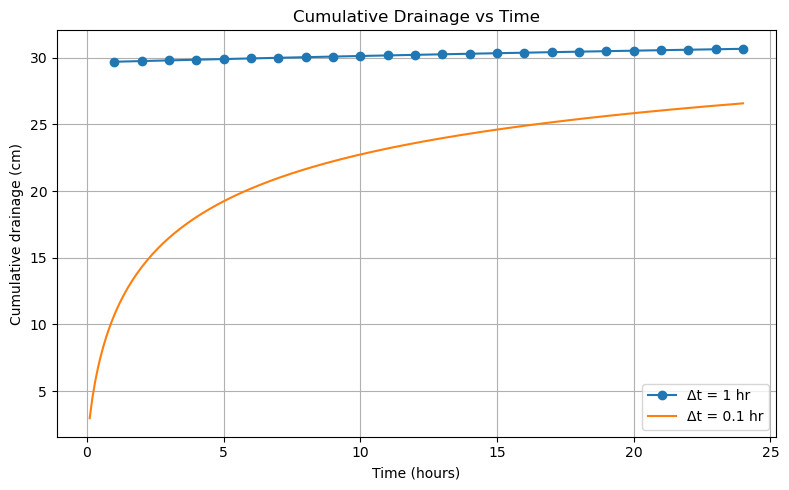

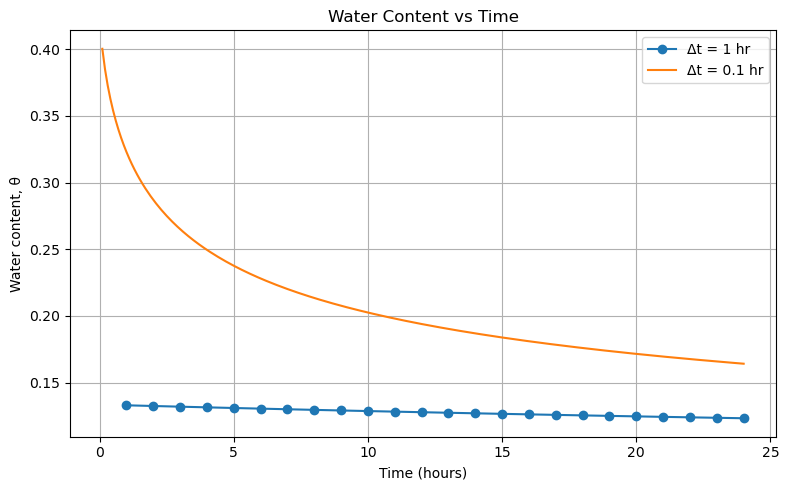

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the two output files
df1 = pd.read_csv("drainage_results_1hr.csv")
df2 = pd.read_csv("drainage_results_0.1hr.csv")

# Make sure time is available
# If your CSV has "Hour" as step number, convert it to actual time
# For the 1 hr file: time = Hour
# For the 0.1 hr file: time = Hour * 0.1
df1["time_h"] = df1["Hour"] * 1.0
df2["time_h"] = df2["Hour"] * 0.1

# -----------------------------
# Plot 1: cumulative drainage vs time
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(df1["time_h"], df1["cumulative_drainage_cm"], marker="o", label="Δt = 1 hr")
plt.plot(df2["time_h"], df2["cumulative_drainage_cm"], label="Δt = 0.1 hr")
plt.xlabel("Time (hours)")
plt.ylabel("Cumulative drainage (cm)")
plt.title("Cumulative Drainage vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: theta_end vs time
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(df1["time_h"], df1["theta_end"], marker="o", label="Δt = 1 hr")
plt.plot(df2["time_h"], df2["theta_end"], label="Δt = 0.1 hr")
plt.xlabel("Time (hours)")
plt.ylabel("Water content, θ")
plt.title("Water Content vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()